# Maze Generation

## Prim's algorith


Generacion de un laberinto por medio del uso del algoritmo de Prim. En términos simples se cera un bloque de paredes y se excava en un punto al azar. A partir de ese punto lista los posibles caminos y selecciona uno al azar, abriendo posibles rutas que se agregan a la lista. Nuevamente al azar se selecciona de las posibles rutas una para excavar y se agregan las nuevas que abrió, el proceso se repite hasta que ya no se pueda crear otros caminos


In [1]:
pip install matplotlib numpy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

Usamos la misma función para dibujar el laberinto y validar nuestra salida

In [6]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def mostrar_laberinto(maze):
    # Definir colores mapa
    cmap = mcolors.ListedColormap(['white', 'black', 'green', 'red'])


    # Mostrar el laberinto
    plt.figure(figsize=(8, 8))
    plt.imshow(maze, cmap=cmap)
    plt.axis('off')
    plt.show()

```
En este caso el core de nuestro algoritmo se
 encuentra en la siguiente validación,
 ya que a partir de una celda revisa los posibles camino en las
  4 direcciones y devuelve las que son posibles
```
    def vecinos_validos(x, y):
        vecinos = []
        for dx, dy in [(-2, 0), (2, 0), (0, -2), (0, 2)]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < n and 0 <= ny < m and maze[nx][ny] == 1:
                vecinos.append((nx, ny, x, y))  # vecino y su origen
        return vecinos


In [30]:


def generar_laberinto_prim(n, m):
    # Para que funcione las dimensiones deben ser impares
    if n % 2 == 0: n += 1
    if m % 2 == 0: m += 1

    # Inicializar el laberinto lleno de muros (1)
    maze = np.ones((n, m), dtype=int)

    def vecinos_validos(x, y):
        vecinos = []
        for dx, dy in [(-2, 0), (2, 0), (0, -2), (0, 2)]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < n and 0 <= ny < m and maze[nx][ny] == 1:
                vecinos.append((nx, ny, x, y))  # vecino y su origen
        return vecinos

    # elegimos un punto aleatorio
    x, y = random.randrange(1, n, 2), random.randrange(1, m, 2)
    maze[x][y] = 0

    # Lista de rutas que puede tomar
    paredes = vecinos_validos(x, y)


    while paredes:
        #elige una ruta aleatorioa y la quita de la lista
        idx = random.randint(0, len(paredes) - 1)
        px, py, ox, oy = paredes.pop(idx)

       # verificamos que esa ruta siga siendo pared para excavar
        if maze[px][py] == 1:
            #Exacavamos ddestino y el camino
            maze[px][py] = 0
            maze[(px + ox)//2][(py + oy)//2] = 0

            # Habierto nuevos caminos, agregamos posibles rutas a la lista
            paredes.extend(vecinos_validos(px, py))

    return maze


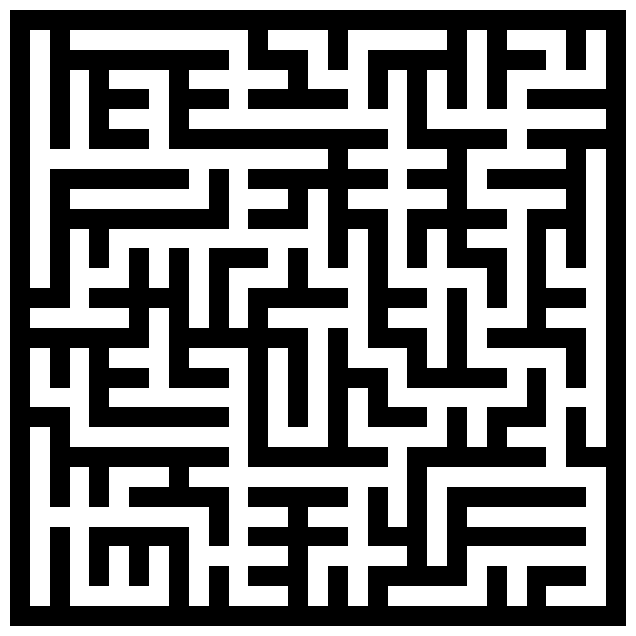

In [34]:
maze = generar_laberinto_prim(31, 31)

mostrar_laberinto(maze)


Usamos los mismos algoritmos para tener una entrada y una salida

In [35]:

def agregar_entrada_salida_aleatoria(maze):
    n, m = maze.shape


    posibles_entradas = [i for i in range(1, n-1) if maze[i][1] == 0 and i % 2 == 1]
    fila_entrada = random.choice(posibles_entradas)
    maze[fila_entrada][0] = 2  # ENTRADA

    posibles_salidas = [i for i in range(1, n-1) if maze[i][m-2] == 0 and i % 2 == 1]
    fila_salida = random.choice(posibles_salidas)
    maze[fila_salida][m-1] = 3  # SALIDA

    return maze



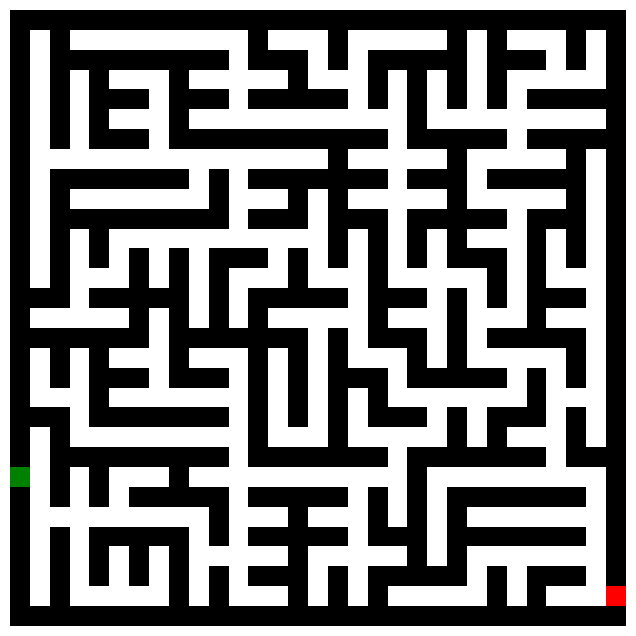

In [36]:
mostrar_laberinto(agregar_entrada_salida_aleatoria(maze))